In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor as SklearnKNNRegressor
from sklearn.neighbors import KNeighborsClassifier as SklearnKNNClassifier

from knn import kNNRegressor, kNNClassifier

np.set_printoptions(precision=4, suppress=True)
np.random.seed(0)

In [2]:
n = 200
X_reg = np.random.uniform(-3, 3, size=(n, 1))
y_reg = np.sin(X_reg[:, 0]) + 0.1 * np.random.randn(n)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=0)

for weights in ['uniform', 'distance']:
    custom = kNNRegressor(n_neighbors=7, weights=weights, p=2)
    custom.fit(Xr_train, yr_train)
    pred_custom = custom.predict(Xr_test)

    sklearn_reg = SklearnKNNRegressor(n_neighbors=7, weights=weights, p=2)
    sklearn_reg.fit(Xr_train, yr_train)
    pred_sklearn = sklearn_reg.predict(Xr_test)

    print(f"weights={weights:9s} max abs diff (custom vs sklearn): "
          f"{np.max(np.abs(pred_custom - pred_sklearn)):.2e}")

weights=uniform   max abs diff (custom vs sklearn): 0.00e+00
weights=distance  max abs diff (custom vs sklearn): 0.00e+00


In [3]:
iris = load_iris()
Xc, yc = iris.data, iris.target
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.3, random_state=0, stratify=yc)

for standarize in [False, True]:
    custom_clf = kNNClassifier(n_neighbors=5, p=2, standarize=standarize)
    custom_clf.fit(Xc_train, yc_train)
    pred_custom = custom_clf.predict(Xc_test)

    if standarize:
        mean, std = Xc_train.mean(axis=0), Xc_train.std(axis=0)
        Xc_train_s, Xc_test_s = (Xc_train - mean) / std, (Xc_test - mean) / std
    else:
        Xc_train_s, Xc_test_s = Xc_train, Xc_test

    sklearn_clf = SklearnKNNClassifier(n_neighbors=5, p=2)
    sklearn_clf.fit(Xc_train_s, yc_train)
    pred_sklearn = sklearn_clf.predict(Xc_test_s)

    agree = np.mean(pred_custom == pred_sklearn)
    acc_custom = np.mean(pred_custom == yc_test)
    acc_sklearn = np.mean(pred_sklearn == yc_test)
    print(f"standarize={str(standarize):5s} agreement with sklearn: {agree:.1%}   "
          f"custom acc: {acc_custom:.1%}   sklearn acc: {acc_sklearn:.1%}")

standarize=False agreement with sklearn: 100.0%   custom acc: 100.0%   sklearn acc: 100.0%
standarize=True  agreement with sklearn: 100.0%   custom acc: 97.8%   sklearn acc: 97.8%


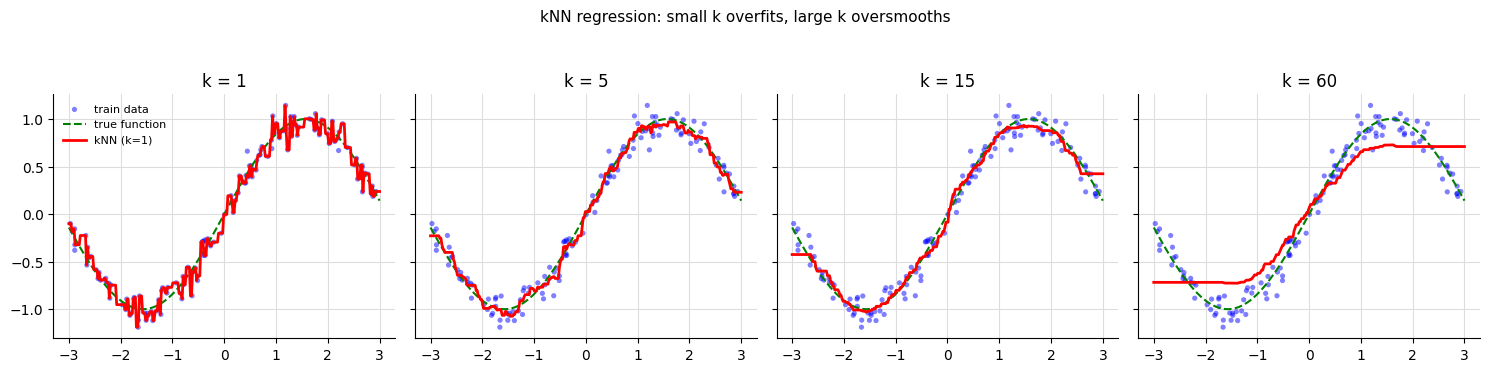

In [4]:
x_grid = np.linspace(-3, 3, 300).reshape(-1, 1)
true_curve = np.sin(x_grid[:, 0])
ks = [1, 5, 15, 60]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
for ax, k in zip(axes, ks):
    model = kNNRegressor(n_neighbors=k, weights='uniform')
    model.fit(Xr_train, yr_train)
    y_grid = model.predict(x_grid)

    ax.scatter(Xr_train[:, 0], yr_train, s=14, color='b', alpha=0.5,
               edgecolors='none', label='train data')
    ax.plot(x_grid[:, 0], true_curve, color='g', linestyle='--', linewidth=1.5,
            label='true function')
    ax.plot(x_grid[:, 0], y_grid, color='r', linewidth=2, label=f'kNN (k={k})')
    ax.set_title(f'k = {k}')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(color='#dddddd', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

axes[0].legend(frameon=False, loc='upper left', fontsize=8)
fig.suptitle('kNN regression: small k overfits, large k oversmooths', fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

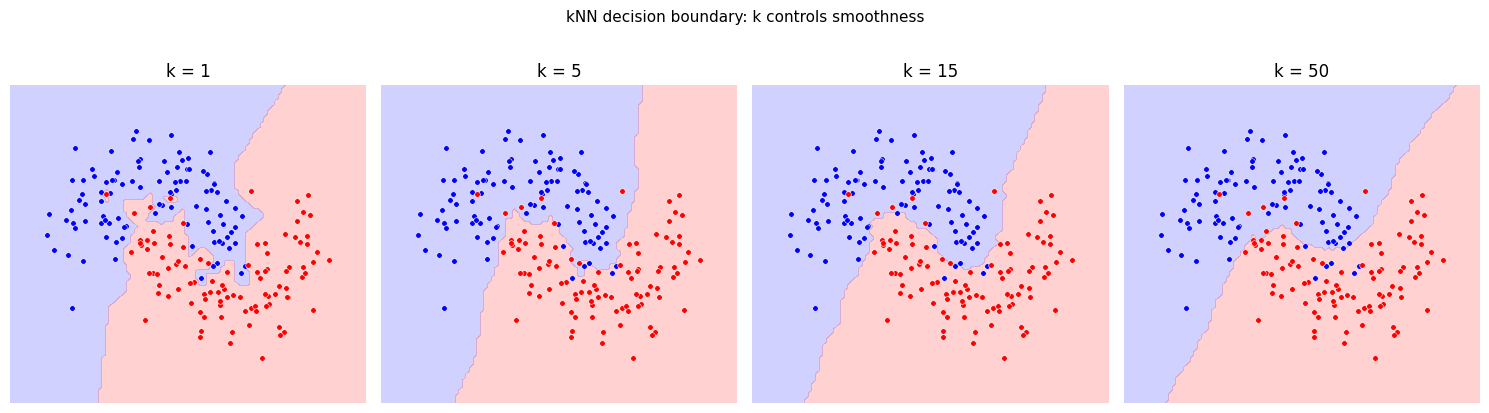

In [5]:
Xm, ym = make_moons(n_samples=200, noise=0.25, random_state=0)

x_min, x_max = Xm[:, 0].min() - 0.5, Xm[:, 0].max() + 0.5
y_min, y_max = Xm[:, 1].min() - 0.5, Xm[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

class_colors = ['b', 'r']
ks_clf = [1, 5, 15, 50]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, k in zip(axes, ks_clf):
    model = kNNClassifier(n_neighbors=k)
    model.fit(Xm, ym)
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=class_colors, alpha=0.18)
    for i, color in enumerate(class_colors):
        mask = ym == i
        ax.scatter(Xm[mask, 0], Xm[mask, 1], s=16, color=color,
                   edgecolors='white', linewidths=0.4)
    ax.set_title(f'k = {k}')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle('kNN decision boundary: k controls smoothness', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

standarize=False test accuracy: 48.9%
standarize=True  test accuracy: 98.9%


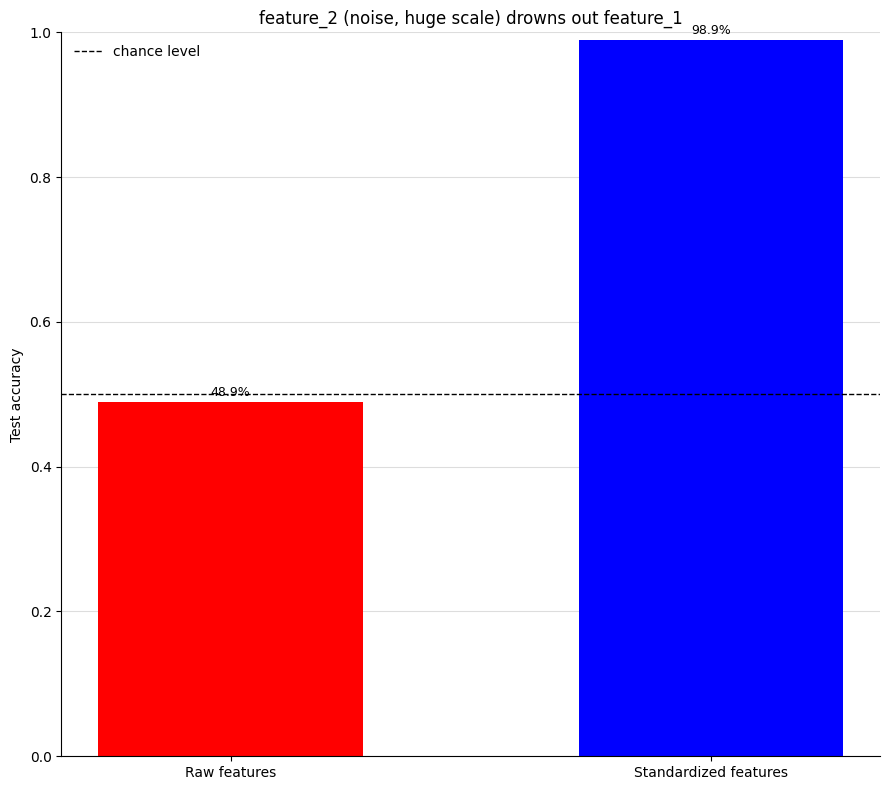

In [8]:
np.random.seed(1)
n_s = 300
y_s = np.random.randint(0, 2, n_s)
feature_1 = y_s + 0.3 * np.random.randn(n_s)          # informative, small scale
feature_2 = np.random.uniform(-1000, 1000, n_s)        # pure noise, huge scale
X_s = np.column_stack([feature_1, feature_2])

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_s, y_s, test_size=0.3, random_state=0, stratify=y_s)

accuracies = {}
for standarize in [False, True]:
    model = kNNClassifier(n_neighbors=5, standarize=standarize)
    model.fit(Xs_train, ys_train)
    pred = model.predict(Xs_test)
    accuracies[standarize] = np.mean(pred == ys_test)
    print(f"standarize={str(standarize):5s} test accuracy: {accuracies[standarize]:.1%}")

fig, ax = plt.subplots(figsize=(9, 8))
labels = ['Raw features', 'Standardized features']
values = [accuracies[False], accuracies[True]]
bars = ax.bar(labels, values, color=['r', 'b'], width=0.55)
ax.axhline(0.5, color='k', linestyle='--', linewidth=1, label='chance level')
ax.set_ylim(0, 1)
ax.set_ylabel('Test accuracy')
ax.set_title('feature_2 (noise, huge scale) drowns out feature_1')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#dddddd', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.1%}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()